# Regular 1

| | |
|---|---|
| **Thời gian** | 90 phút |
| **Tổng điểm** | **10,0 điểm** |
| **Hình thức** | Làm trực tiếp trên notebook này. Không xóa đề. |

---

### Rules
1. Import các thư viện đã học.
2. Mọi nhận xét viết ngắn gọn, dựa trên **kết quả bạn vừa tính** — không copy insight có sẵn.
3. Chạy cell **theo thứ tự từ trên xuống**.
4. Biểu đồ phải có title và nhãn trục. In kết quả số ra màn hình.
5. Lưu file ở ổ T, đặt tên file MSSV_HoTen.ipynb.

### Cách chấm / Grading
- Code không chạy được: 0 điểm.

### Bảng điểm tóm tắt

| Phần | Nội dung | Điểm |
|---|---|---|
| 0 | Import, load, copy | 0,5 |
| 1 | Inspection (explore, duplicate, missing) | 2,0 |
| 2 | Data cleaning (missing, dtype, feature) | 3,5 |
| 3 | EDA (top items, outlier, correlation) | 3,0 |
| 4 | Summary & insights | 1,0 |
| **Tổng** | | **10,0** |

## Dataset Description 

- **Transaction ID**: mã giao dịch
- **Item**: món (Coffee, Cake, Cookie, Salad, …)
- **Quantity**: số lượng
- **Price Per Unit**: đơn giá
- **Total Spent**: tổng tiền dòng
- **Payment Method**: Credit Card / Cash / Digital Wallet
- **Location**: Takeaway hoặc In-store
- **Transaction Date**: ngày giao dịch


---
## Phần 0 — Prepare Data (**0,5 đ**)


Import thư viện cần dùng. Đọc file dirty_cafe_sales.csv.

In [1]:
# df =?
import pandas as pd
import numpy as np 
#import matplotlib.pyplot as plt

df = pd.read_csv('dirty_cafe_sales.csv')
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


Make a copy from df

In [2]:
# df_original = ?
df_original = df.copy()

---
## Phần 1 — Initial Data Inspection (**2,0 đ**)

### Câu 1.1 — Explore the data (**0,5 đ**)


In **10 dòng đầu**

In [3]:
#Your code here
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In **thông tin dataframe** (số dòng, cột, dtype, non-null).

In [4]:
# Your code here
print(df.shape[0])
print(df.shape[1])
print(df.dtypes)

10000
8
Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object


Cho biết **giá trị duy nhất** mỗi cột

In [6]:
# Your code here
df.columns.unique()


Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

### Câu 1.2 — Duplicate (**0,5 đ**)

**Yêu cầu**
- Đếm số dòng trùng. Nếu có: quyết định xóa hay giữ, chạy code, giải thích, và so sánh dữ liệu trước/sau xóa.



In [7]:
#  Your code here
df1 = df.duplicated().sum()
df1

np.int64(0)

khong co du lieu trung lap

In [21]:
#truong hop neu co
df.drop_duplicates()
df1 = df.duplicated().sum()
df1

np.int64(0)

nên xóa vì dữ liệu lập lại có thể làm lệch dữ liệu, và khiến dữ liệu thiếu sự chính xác

### Câu 1.3 — Missing values (**1,0 đ**)

**Yêu cầu**
1. Đếm missing **theo từng cột** (**0,3 đ**).
2. Tính **% missing trên toàn bộ dataset** (**0,3 đ**).
3. Vẽ **bar chart** missing (**0,4 đ**).

In [31]:
#  Your code here
missing = df.isnull().sum()


In [32]:
df_c = missing.sum() / df.shape[0]
df_c

np.float64(0.184)

<Axes: >

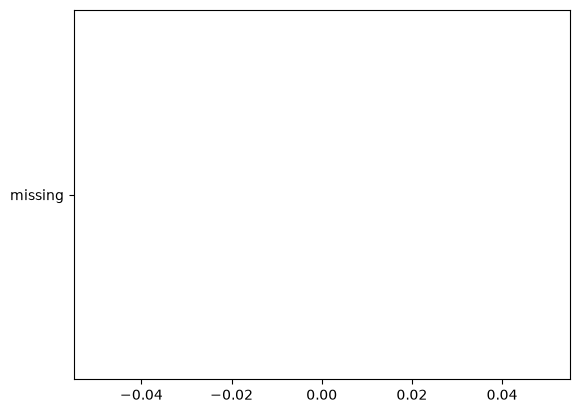

In [14]:
import seaborn as sns
sns.barplot('missing')

---
## Phần 2 — Data Cleaning (**3,5 đ**)



### Câu 2.1 — Handle missing values (**1,5 đ**)

Làm theo **từng cột** ở bảng dưới. Sau khi xử lý, in lại số missing để kiểm tra.

| Cột | Loại | Cách xử lý |
|---|---|---|
| Transaction ID | ID | Thiếu thì **xóa dòng** (không suy ra được) |
| Quantity | Số | Nếu đủ Price Per Unit và Total Spent → Quantity = Total Spent / Price Per Unit. Phần còn thiếu → **median** |
| Price Per Unit | Số | Nếu đủ Quantity và Total Spent → Price Per Unit = Total Spent / Quantity. Phần còn thiếu → **median** |
| Total Spent | Số | Nếu đủ Quantity và Price Per Unit → Total Spent = Quantity × Price Per Unit. Phần còn thiếu → **median** |
| Item | Nhóm | Fill missing — chọn cách ở bước 3 |
| Payment Method | Nhóm | Fill missing — chọn cách ở bước 3 |
| Location | Nhóm | Fill missing — chọn cách ở bước 3 |
| Transaction Date | Ngày | Chưa fill ở câu này — convert ở câu 2.2 |


**Bước 1 — Đổi giá trị giả thành missing (**0,3 đ**)**

Trên mọi cột: ERROR và UNKNOWN không phải dữ liệu thật → đổi thành NaN, rồi mới fill.
Áp dụng cho: Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, Transaction Date.

In [16]:
# Your code here --> replace
cols = ['Item', 'Quantity', 'Price Per Unit', 
        'Total Spent', 'Payment Method', 
        'Location', 'Transaction Date']

# Thay thế ERROR và UNKNOWN bằng NaN
df[cols] = df[cols].replace(['ERROR', 'UNKNOWN'], np.nan)

Fill numeric columns with median or mean. (1đ)

Ưu tiên **suy ra** Quantity / Price / Total từ 2 trong 3 cột (vì Total ≈ Quantity × Price), rồi mới fill median cho phần còn thiếu. Median bền hơn mean với dữ liệu lệch.

**Ví dụ số**

| Trường hợp | Quantity | Price Per Unit | Total Spent | Công thức |
|---|---|---|---|---|
| Thiếu Total | 2 | 5 | NaN | Total = 2 × 5 = 10 |
| Thiếu Quantity | NaN | 5 | 10 | Quantity = 10 / 5 = 2 |
| Thiếu Price | 2 | NaN | 10 | Price = 10 / 2 = 5 |
| Thiếu 2–3 cột | NaN | NaN | 10 | Không suy được → fill median |

**Mẫu code:** 3 trường hợp suy ra + 1 dòng fill median. Gỡ dấu # rồi chạy.

In [19]:
df[["Quantity", "Price Per Unit", "Total Spent"]] = df[["Quantity", "Price Per Unit", "Total Spent"]].astype(float)

# 1) Thiếu Total Spent, còn Quantity và Price → nhân
mask_total = df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()
df.loc[mask_total, "Total Spent"] = df.loc[mask_total, "Quantity"] * df.loc[mask_total, "Price Per Unit"]

# 2) Thiếu Quantity, còn Total và Price → chia
mask_Qty = df["Quantity"].isna() & df["Total Spent"].notna() & df["Price Per Unit"].notna()
df.loc[mask_Qty, "Quantity"] = df.loc[mask_Qty, "Total Spent"] / df.loc[mask_Qty, "Price Per Unit"]

# 3) Thiếu Price, còn Total và Quantity → chia
mask_Price = df["Price Per Unit"].isna() & df["Quantity"].notna() & df["Total Spent"].notna()
df.loc[mask_Price, "Price Per Unit"] = df.loc[mask_Price, "Total Spent"] / df.loc[mask_Price, "Quantity"]



# Your code here

In [20]:
# 4) Còn NaN thì fill median (làm tương tự 3 cột số)
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Total Spent"] = df["Total Spent"].fillna(df["Total Spent"].median())
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())


**Bước 3 — Cột nhóm (**0,4 đ**)** — Item, Payment Method, Location

Fill NaN bằng Unknown. 

**Mẫu code** (chỉ cột Item). Làm tương tự cho Payment Method và Location.

In [22]:
# Mẫu: fill Item
df["Item"] = df["Item"].fillna("Unknown")
df["Payment Method"] = df["Payment Method"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")

# Your code here


**Bonus** Tại sao không fill mode: 3 cột này ? (+0.5)

# your explaination here
bởi vì 3 cột này là dữ liệu quan trọng, thay bằng mode có thể làm sai lệch dữ liệu

### Câu 2.2 — Fix incorrect data types (**0,8 đ**)

**Yêu cầu — convert:**
- Quantity → integer
- Price Per Unit, Total Spent → float
- Transaction Date → datetime

**Hướng dẫn làm**
- Số: astype.
- Ngày: to_datetime, lỗi thì thành NaT.
- In dtypes sau khi convert.



In [23]:
#  Your code here
df['Price Per Unit'].astype(float)

0       2.0
1       3.0
2       1.0
3       5.0
4       2.0
       ... 
9995    2.0
9996    1.0
9997    2.0
9998    1.0
9999    4.0
Name: Price Per Unit, Length: 10000, dtype: float64

### Câu 2.3 —  Create new features (**1,2 đ**)

**Yêu cầu**
1. Tách Year, Month, Day of week từ Transaction Date (**0,6 đ**).
2. Total Spent ≈ Quantity × Price Per Unit (**0,6 đ**).



In [28]:
# Your code here
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df["Year"] = df["Transaction Date"].dt.year
df["Month"] = df["Transaction Date"].dt.month
df["DayOfWeek"] = df["Transaction Date"].dt.day_name()  

df["Total Spent"] = df["Quantity"].astype(float) * df["Price Per Unit"].astype(float)

---
## Phần 3 — Exploratory Data Analysis (**3,0 đ**)

Làm EDA trên dữ liệu đã clean.

### Câu 3.1 — Món bán chạy (**1,0 đ**)

**Yêu cầu**
1. Bảng top 5 Item theo tổng Quantity (**0,5 đ**).
2. Bar plot top 5 (**0,5 đ**).

**Hướng dẫn làm**
- Group theo Item, cộng Quantity, sắp xếp giảm dần, lấy 5 món đầu.
- Bar plot: có title và nhãn trục.
- Nếu đã fill Unknown: ghi 1 dòng lý do có/không loại Unknown khỏi top 5.



In [33]:
# Your code here
top_5 = (df.groupby("Item")["Quantity"].sum().sort_values(ascending=False).head(5))
print(top_5)

Item
Coffee      3552.0
Juice       3514.0
Salad       3477.0
Cake        3474.0
Sandwich    3439.0
Name: Quantity, dtype: float64


C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_25232\1861667329.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.index, y=top_5.values, palette="viridis")


<Axes: xlabel='Item'>

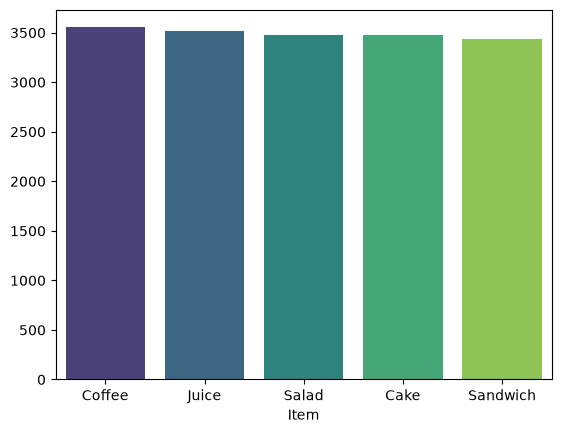

In [34]:
sns.barplot(x=top_5.index, y=top_5.values, palette="viridis")

### Câu 3.2 — Outlier (**1,0 đ**)

**Yêu cầu**
1. Boxplot Quantity và/hoặc Total Spent (**0,5 đ**).
2. Quyết định keep / cap / remove và giải thích (**0,5 đ**).

**Hướng dẫn làm**
- Dùng boxplot.
- Có thể dùng IQR: Q1 và Q3 là quantile 0.25 và 0.75; fence = Q1 − 1.5×IQR và Q3 + 1.5×IQR.


<Axes: xlabel='Quantity'>

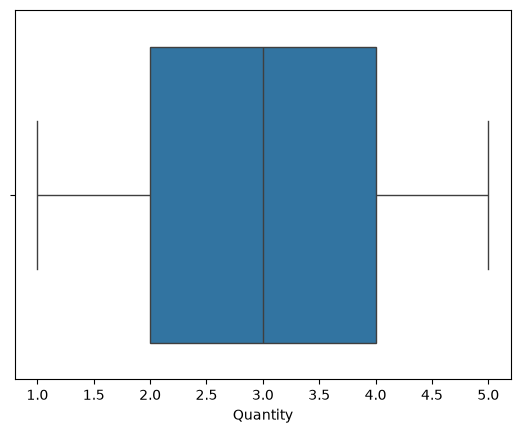

In [35]:
# Your code here
sns.boxplot(x=df["Quantity"])

<Axes: xlabel='Total Spent'>

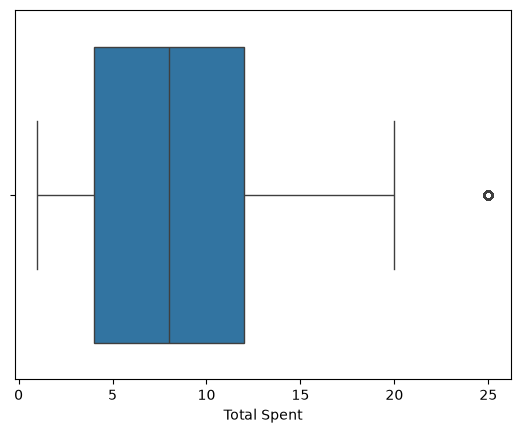

In [36]:
sns.boxplot(x=df["Total Spent"])

**Bonus (+0,25 đ**): Điểm khác biệt giữa IQR và clip là gì?.

# your explaination here

-IQR là cách phát hiện outlier dựa trên phân phối dữ liệu.    
-clip là cách ép giá trị về ngưỡng mà mình tự đặt ra   

### Câu 3.3 — Correlation (**1,0 đ**)

**Yêu cầu**
1. Ma trận tương quan các cột số Quantity, Price Per Unit, Total Spent (**0,3 đ**).
2. Heatmap (**0,3 đ**).
3. Viết mối quan hệ nổi bật (**0,4 đ**).

**Hướng dẫn làm**
- Nhận xét từng cặp: dương/âm, mạnh/yếu.


In [37]:
# Your code here
corr_matrix = df[["Quantity", "Price Per Unit", "Total Spent"]].corr()
print(corr_matrix)

                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.006807     0.704127
Price Per Unit  0.006807        1.000000     0.646746
Total Spent     0.704127        0.646746     1.000000


<Axes: >

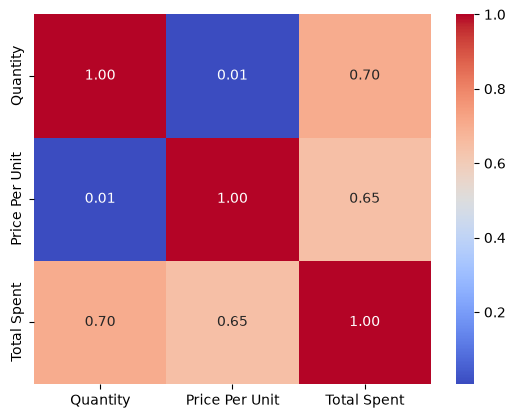

In [38]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

---
## Phần 4 — Summary & Insights (**1,0 đ**)

### Câu 4.1 (**1,0 đ**)

Điền vào khung bên dưới. Lấy số từ output bạn đã chạy. Không bịa số.


**Câu 4.1 — điền vào chỗ trống**

**(1) Chất lượng dữ liệu — 0,3 đ**  
Toàn bộ dataset thiếu khoảng 68,26 %. Cột thiếu nhiều nhất là Location (khoảng 32,65 %).  
Cột số em fill bằng …… ; cột nhóm em fill bằng …… .  
Ý nghĩa (1 câu): ……

**(2) Món bán chạy — 0,4 đ**  
Top 1 theo tổng Quantity là …… , khoảng …… (đơn vị).  
Em có loại Unknown khỏi bảng top 5 không? Có / Không. Lý do (1 câu): ……  
Ý nghĩa cho quán (1 câu): ……

**(3) Chọn đúng 1 trong 2 — 0,3 đ**

□ Outlier: cột …… có / không có outlier rõ. Em chọn keep / cap / remove vì ……

□ Tương quan: cặp …… và …… có hệ số corr ≈ …… (dương/âm, mạnh/yếu). Ý nghĩa: ……


---
## Bonus — Encoding (**+0,5 đ**)

**Yêu cầu**
1. One-hot 1–2 cột category ít nhóm (ví dụ Payment Method, Location). Giữ cột gốc.
2. Label encoding cột nhiều nhóm hơn (ví dụ Item). Nói rõ số không có thứ tự.

**Hướng dẫn làm**
- One-hot: get_dummies rồi nối lại dataframe.
- Label: LabelEncoder, tạo cột mới (ví dụ Item_label).


In [ ]:
# Bonus — Your code here (optional)
